In [6]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import shap
import joblib

In [9]:
# 2. LOAD DATASET

df = pd.read_csv('C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\star_classification1.csv')
print(df.head())

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [10]:
# -----------------------------------------------------
# 3. DATA PREPROCESSING
# -----------------------------------------------------

if 'obj_ID' in df.columns:
    df = df.drop(['obj_ID'], axis=1)

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# -----------------------------------------------------
# 4. HANDLE IMBALANCE (OPTIONAL)
# -----------------------------------------------------

# Comment this if training becomes slow
# sm = SMOTE(random_state=42)
# X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)

In [11]:
# -----------------------------------------------------
# 5. MODEL TRAINING (OPTIMIZED)
# -----------------------------------------------------

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)
xgb.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Random Forest Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11860
           1       0.97      0.93      0.95      3797
           2       0.99      1.00      1.00      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

XGBoost Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11860
           1       0.97      0.93      0.95      3797
           2       0.99      1.00      0.99      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



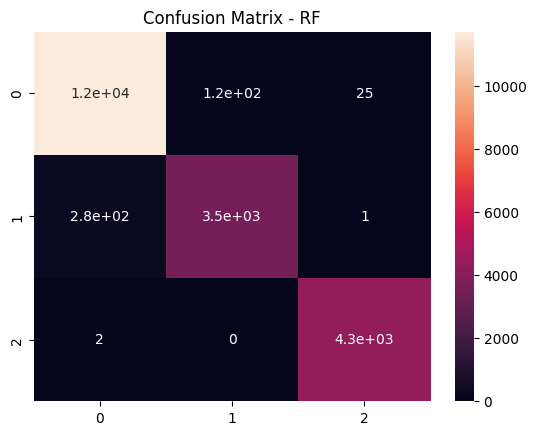

In [12]:
# -----------------------------------------------------
# 6. EVALUATION
# -----------------------------------------------------

print("Random Forest Results:")
print(classification_report(y_test, rf.predict(X_test_scaled)))

print("XGBoost Results:")
print(classification_report(y_test, xgb.predict(X_test_scaled)))

sns.heatmap(confusion_matrix(y_test, rf.predict(X_test_scaled)), annot=True)
plt.title("Confusion Matrix - RF")
plt.show()

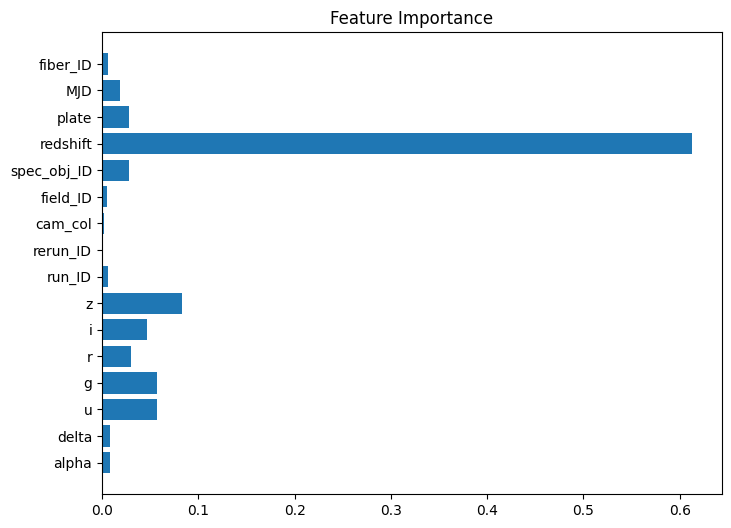

In [13]:
# -----------------------------------------------------
# 7. FEATURE IMPORTANCE
# -----------------------------------------------------

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

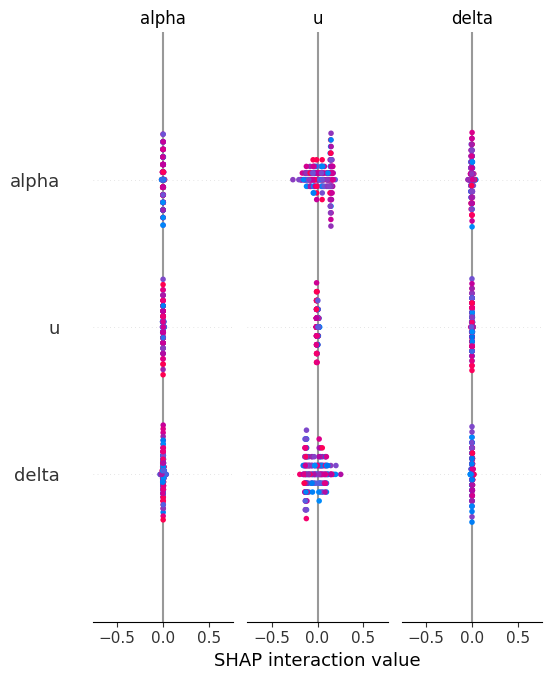

In [14]:
# -----------------------------------------------------
# 8. EXPLAINABILITY (FAST SHAP)
# -----------------------------------------------------

# Use small samples to avoid slow computation
X_sample = X_test_scaled[:200]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=features)


In [15]:
# -----------------------------------------------------
# 9. SAVE MODEL
# -----------------------------------------------------

joblib.dump(rf, 'stellar_rf_model.pkl')
joblib.dump(xgb, 'stellar_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [16]:
def predict_object(input_data):
    input_scaled = scaler.transform([input_data])
    prediction = rf.predict(input_scaled)
    return le.inverse_transform(prediction)


In [17]:
# 11. EDUCATIONAL OUTPUT FUNCTION
def get_object_details(prediction_class):
    details = {
        'STAR': 'A star is a luminous sphere of plasma held together by gravity. It produces energy through nuclear fusion.',
        'GALAXY': 'A galaxy is a massive system of stars, stellar remnants, gas, dust, and dark matter, bound together by gravity.',
        'QSO': 'Quasar (QSO) is a very energetic and distant active galactic nucleus, powered by a supermassive black hole.'
    }
    return details.get(prediction_class, 'No details available')


In [18]:
# -----------------------------------------------------
# 10. PREDICTION FUNCTION (CORRECT PIPELINE)
# -----------------------------------------------------

def predict_object(input_data):
    input_scaled = scaler.transform([input_data])
    prediction = rf.predict(input_scaled)
    return le.inverse_transform(prediction)


In [19]:
# -----------------------------------------------------
# 11. KNOWLEDGE ENGINE (ADVANCED FEATURE)
# -----------------------------------------------------

def get_object_details(prediction_class):
    details = {
        'STAR': "A star is a massive luminous sphere of plasma that generates energy through nuclear fusion.",
        'GALAXY': "A galaxy is a huge system containing billions of stars, gas, dust, and dark matter.",
        'QSO': "A quasar is an extremely bright and distant object powered by a supermassive black hole."
    }
    return details.get(prediction_class, "No details available")


In [20]:
# -----------------------------------------------------
# 12. CNN MODEL (IMAGE CLASSIFICATION - FUTURE)
# -----------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN ready (train when image dataset is available)")

c:\MSc.FY Projects\Stellar Object Prediction\objenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN ready (train when image dataset is available)


In [21]:
# -----------------------------------------------------
# 13. EXAMPLE USAGE (FINAL FIXED)
# -----------------------------------------------------

example_input = X.iloc[0]   # RAW data (important!)

predicted_class = predict_object(example_input)[0]
details = get_object_details(predicted_class)

print(f"Predicted Class: {predicted_class}")
print(f"Details: {details}")

Predicted Class: GALAXY
Details: A galaxy is a huge system containing billions of stars, gas, dust, and dark matter.


c:\MSc.FY Projects\Stellar Object Prediction\objenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# -----------------------------------------------------
# 14. READY FOR DEPLOYMENT
# -----------------------------------------------------

print("\nProject Ready: Model + Explainability + Knowledge Engine + Deployment Support")



Project Ready: Model + Explainability + Knowledge Engine + Deployment Support


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# Load your dataset
df = pd.read_csv("star_classification1.csv")  # replace with your dataset

# Create LabelEncoder
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])  # target column

# Save it as .pkl
joblib.dump(le, "label_encoder.pkl")
print("✅ LabelEncoder saved as label_encoder.pkl")


FileNotFoundError: [Errno 2] No such file or directory: 'star_classification1.csv'